In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [4]:
# Pandasでデータを読み込み、その内容を何件か確認
data = pd.read_csv('soccer_data.csv')

In [5]:
data.shape

(2140, 4)

In [6]:
data.head()

,Home,Away,Home_Goals,Away_Goals
0,G-Olympus,Koban,2,3
1,Hirostar,Urawind,1,0
2,Nagomi,Shimizun,1,0
3,Savan Taurus,C-Osario,0,0
4,Sapporia,Iwana,0,0


In [ ]:
# Homeチームのゴール数の平均
home_goal_mean = data['Home_Goals'].mean()

# Awayチームのゴール数の平均
away_goal_mean = data['Away_Goals'].mean()

np.float64(1.4177570093457943)

In [58]:
# Homeのデータ
data_home_Urawind = data.query('Home == "Urawind"')

# Awayのデータ
data_Away_Urawind = data.query('Away == "Urawind"')


In [68]:
data_home_Urawind

,Home,Away,Home_Goals,Away_Goals
12,Urawind,Kashiwave,1,0
31,Urawind,Kawasari Foresta,1,1
48,Urawind,Koban,2,0
78,Urawind,Yomoyama Mystic,1,2
94,Urawind,Ablihex Nimbus,1,1
...,...,...,...,...
2062,Urawind,C-Osario,1,2
2081,Urawind,Koban,4,0
2090,Urawind,Kashiwave,3,2
2105,Urawind,Kashirama,3,1


Text(0, 0.5, 'ゴール数が一致する試合数')

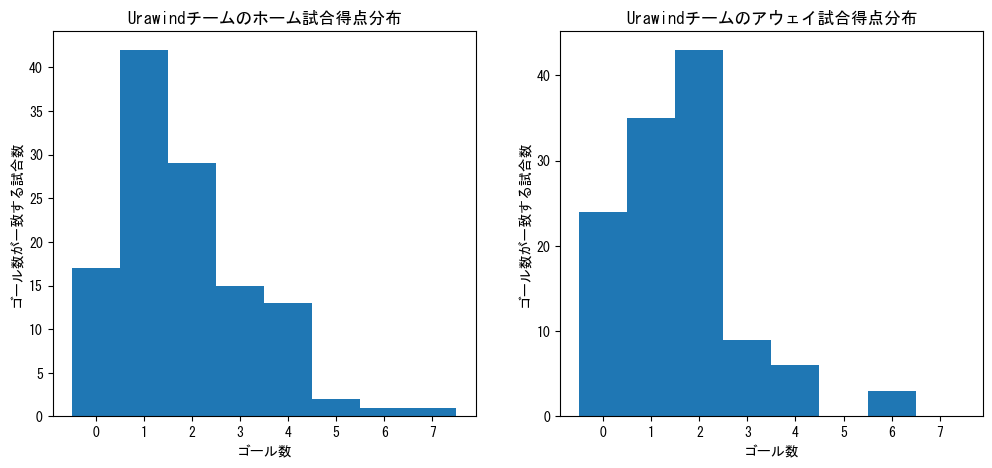

In [74]:
# Urawindチームのデータ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.rcParams['font.family'] = 'MS Gothic'

max_goals = np.maximum(data_home_Urawind['Home_Goals'].max(),
                       data_Away_Urawind['Away_Goals'].max()) + 2
# Home
axes[0].hist(data_home_Urawind['Home_Goals'], bins=range(0, max_goals), align='left')
axes[0].set_title('Urawindチームのホーム試合得点分布')
axes[0].set_xlabel('ゴール数')
axes[0].set_ylabel('ゴール数が一致する試合数')

# Away
axes[1].hist(data_Away_Urawind['Away_Goals'], bins=range(0, max_goals), align='left')
axes[1].set_title('Urawindチームのアウェイ試合得点分布')
axes[1].set_xlabel('ゴール数')
axes[1].set_ylabel('ゴール数が一致する試合数')


In [ ]:
# Homeのデータ
data_home_Kashirama = data.query('Home == "Kashirama"')

# Awayのデータ
data_Away_Kashirama = data.query('Away == "Kashirama"')

Text(0, 0.5, 'ゴール数が一致する試合数')

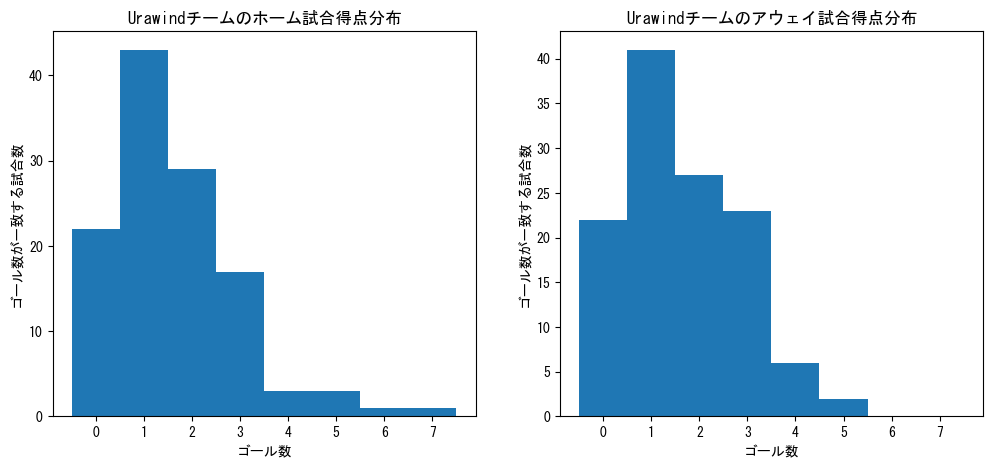

In [77]:
# Kashiramaチームのデータ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.rcParams['font.family'] = 'MS Gothic'

max_goals = np.maximum(data_home_Kashirama['Home_Goals'].max(),
                       data_Away_Kashirama['Away_Goals'].max()) + 2

# Home
axes[0].hist(data_home_Kashirama['Home_Goals'], bins=range(0, max_goals), align='left')
axes[0].set_title('Urawindチームのホーム試合得点分布')
axes[0].set_xlabel('ゴール数')
axes[0].set_ylabel('ゴール数が一致する試合数')

# Away
axes[1].hist(data_Away_Kashirama['Away_Goals'], bins=range(0, max_goals), align='left')
axes[1].set_title('Urawindチームのアウェイ試合得点分布')
axes[1].set_xlabel('ゴール数')
axes[1].set_ylabel('ゴール数が一致する試合数')

In [92]:
# 一般化線形モデルを作成 1つ目：Away_Goals、Home、Away
model_1 = smf.glm('Home_Goals ~ Away_Goals + Home + Away', data=data, family=sm.families.Poisson()).fit()
print("１つ目 AIC:", model_1.aic)

１つ目 AIC: 6448.857703135879


In [93]:
# 一般化線形モデルを作成 2つ目：Home と Away_Goals
model_2 = smf.glm('Home_Goals ~ Away_Goals + Home', data=data, family=sm.families.Poisson()).fit()
print("２つ目 AIC:", model_2.aic)

２つ目 AIC: 6472.639085015406


In [131]:
# 最適なモデルを表示
best_model = model_1 if model_1.aic < model_2.aic else model_2

print(best_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Home_Goals   No. Observations:                 2140
Model:                            GLM   Df Residuals:                     2087
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3171.4
Date:                Tue, 14 Oct 2025   Deviance:                       2433.7
Time:                        14:17:29   Pearson chi2:                 2.13e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.1027
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
# DataFrame作成
Home_1 = pd.DataFrame({'Away_Goals':[0], 'Home':['Urawind'], 'Away':['Kashirama']})
Home_2 = pd.DataFrame({'Away_Goals':[2], 'Home':['Urawind'], 'Away':['Kashirama']})


In [132]:
# Awayのチームが 0 点だったときのHomeチームの得点の予測値
Home_goals_1 = best_model.predict(Home_1)

# Awayのチームが 2 点だったときのHomeチームの得点の予測値
Home_goals_2 = best_model.predict(Home_2)

print(Home_goals_1)
print(Home_goals_2)

# KashiramaのAwayでの平均得点
mean_away_Kashirama_goal = data.query('Away == "Kashirama"')['Away_Goals'].mean()

print(mean_away_Kashirama_goal)

0    1.575325
dtype: float64
0    1.730129
dtype: float64
1.6363636363636365


In [125]:
# 上記の平均得点を λ としたポアソン分布から乱数を100個生成
np.random.seed(1)
away_Kashirama_goals = np.random.poisson(lam=mean_away_Kashirama_goal, size=100)

In [ ]:
home_Urawind_goals = []

for away_Kashirama_goal in away_Kashirama_goals:
    df_Urawind = pd.DataFrame({'Away_Goals':[away_Kashirama_goal], 'Home':['Urawind'], 'Away':['Kashirama']})
    home_Urawind_goals.append(best_model.predict(df_Urawind)[0])

# 得点予測値
home_Urawind_goals

# 勝敗予測
win_Urawind = home_Urawind_goals > away_Kashirama_goals
total_win_Urawind = win_Urawind.sum()

# 勝つ確率
win_probability = total_win_Urawind / 100 * 100

print("勝つ確率：", win_probability, "％")

勝つ確率： 53.0 ％
